# K-Means - Instacart (simple)


Evaluación del número de clusters y ajuste final del modelo. Se comparan las métricas internas y se analizan los perfiles obtenidos para las configuraciones seleccionadas.


In [13]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from modeling_functions import kmeans_metrics, plot_clustering_metrics, analyze_clusters, fit_clustering_model, save_clustering_metrics
import pandas as pd
import time

## Carga y preparación de los datos


In [14]:
df_scaled = pd.read_csv("../../../scaled_data/instacart_scaled.csv")

In [15]:
df_simple = pd.read_csv("../../../simple_datasets/instacart_model_simple.csv")

In [16]:
df_scaled = df_scaled[df_scaled.columns.intersection(df_simple.columns)]

In [17]:
# Variables utilizadas para clustering
X = df_scaled.drop(columns=["user_id"], errors="ignore")

## Evaluación del número de clusters


In [18]:
resultados_kmeans = kmeans_metrics(X)

In [ ]:
tabla_metricas = save_clustering_metrics(
    resultados_kmeans,
    model_name="kmeans",
    dataset_name="instacart",
    dataset_version="simple",
)

print("Métricas consolidadas en ../../../results/clustering_metrics.csv")
display(tabla_metricas)

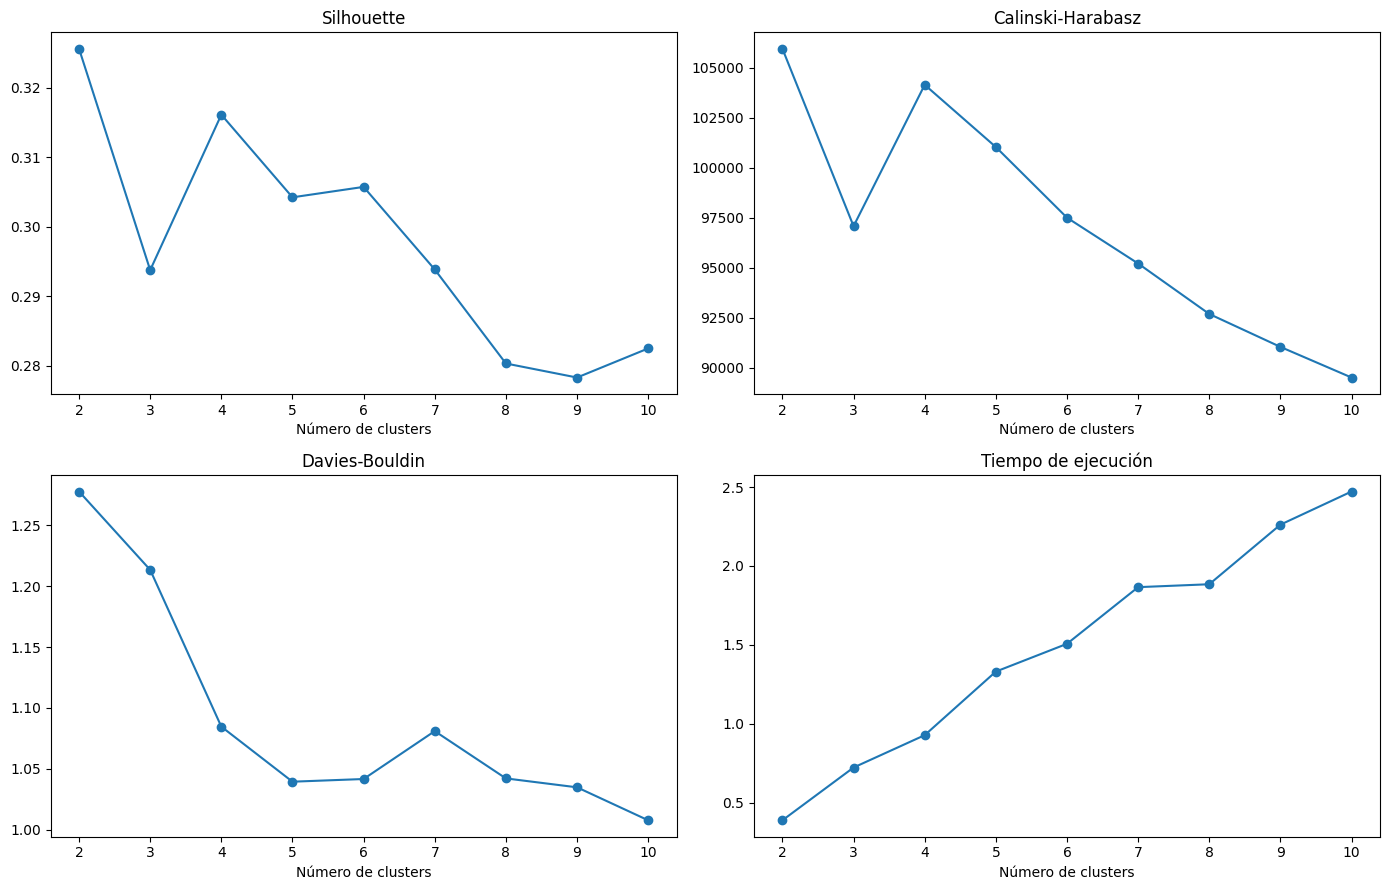

In [19]:
plot_clustering_metrics(resultados_kmeans)

## Ajuste final y perfil de los clusters


In [21]:
modelo, labels = fit_clustering_model(
    model_name="kmeans",
    k=4,
    X=X
)

cluster_sizes, porcentajes, perfil_clusters, df_clusterizado = analyze_clusters(
    labels,
    df_scaled,
    df_simple,
    id_col="user_id"
)

print("K-MEANS CON k = 4")

print("\nTamaño de los clusters:")
display(cluster_sizes)

print("\nPorcentaje de clientes:")
display(porcentajes)

print("\nPerfil medio de los clusters:")
display(perfil_clusters)


K-MEANS CON k = 4

Tamaño de los clusters:


cluster
0    52256
1    61085
2    40455
3    52413
Name: count, dtype: int64


Porcentaje de clientes:


cluster
0    25.34
1    29.62
2    19.62
3    25.42
Name: proportion, dtype: float64


Perfil medio de los clusters:


,recency,frequency,avg_basket_size
cluster,,,
0,8.614,7.657,11.650
1,28.185,9.001,12.443
2,23.006,8.351,3.685
3,7.933,36.767,10.192


- Cluster 0 – Clientes recientes de cesta grande: presentan una recencia baja, por lo que han comprado recientemente, una frecuencia de compra moderada y un tamaño medio de cesta elevado. Representan clientes relativamente activos que realizan pedidos grandes, aunque sin alcanzar una frecuencia especialmente alta.
- Cluster 1 – Clientes menos recientes de cesta grande: muestran una recencia elevada y una frecuencia moderada, pero realizan las cestas de mayor tamaño entre los cuatro grupos. Se caracterizan por comprar con menor actualidad, aunque cuando realizan un pedido adquieren una cantidad considerable de productos.
- Cluster 2 – Clientes ocasionales de cesta pequeña: presentan una recencia relativamente elevada, una frecuencia moderada-baja y, especialmente, un tamaño de cesta muy reducido. Representan clientes con una actividad limitada y compras de menor volumen.
- Cluster 3 – Clientes frecuentes y recientes: constituyen el segmento más activo, con la menor recencia y una frecuencia de compra muy superior al resto. Además, realizan cestas de tamaño considerable, por lo que representan a los clientes con un comportamiento de compra más recurrente y consolidado.

In [22]:
modelo, labels = fit_clustering_model(
    model_name="kmeans",
    k=2,
    X=X
)

cluster_sizes, porcentajes, perfil_clusters, df_clusterizado = analyze_clusters(
    labels,
    df_scaled,
    df_simple,
    id_col="user_id"
)


print(f"K-MEANS CON k = {2}")
print("\nTamaño de los clusters:")
display(cluster_sizes)

print("\nPorcentaje de clientes:")
display(porcentajes)

print("\nPerfil medio de los clusters:")
display(perfil_clusters)

K-MEANS CON k = 2

Tamaño de los clusters:


cluster
0    100807
1    105402
Name: count, dtype: int64


Porcentaje de clientes:


cluster
0    48.89
1    51.11
Name: proportion, dtype: float64


Perfil medio de los clusters:


,recency,frequency,avg_basket_size
cluster,,,
0,26.548,8.171,9.411
1,7.989,22.686,10.468


- Cluster 0 – Clientes menos recientes y de actividad moderada: presentan una recencia elevada, una frecuencia de compra relativamente baja y un tamaño medio de cesta cercano a 9,4 productos. Representan clientes que compran con cierta regularidad, pero cuya actividad reciente es reducida.
- Cluster 1 – Clientes frecuentes y recientes: presentan una recencia muy baja y una frecuencia de compra muy superior al otro grupo. Además, realizan cestas ligeramente mayores, con una media cercana a 10,5 productos. Representan, por tanto, el segmento de clientes más activos y recurrentes.